# Tool Hierarchy Visualizer

Renders the full **ToolNode tree** across all three abstraction levels:

| Level | Description | Definition | Implementation |
|-------|-------------|------------|----------------|
| **L0** | Native atoms — raw mouse/keyboard calls | Python (`primitives.py`) | `atom_*` pyautogui wrappers |
| **L1** | Semantic operands — UI-aware single steps | JSON (`state/tools/*.json`) | `actions.py` / `operations.py` |
| **L2** | Compound multi-step flows | JSON (`state/tools/*.json`) | Pure `"steps"` composition — no Python needed |

Levels are **auto-computed**: a node's level = `max(child.level) + 1`. Leaf nodes (no children) are L0.

All tools above L0 are loaded from `state/tools/*.json` at startup via `core.tools.loader.load_tools_from_dir()`.

In [4]:
import sys, os
from pathlib import Path

# Works whether run from notebooks/ or project root
_here = Path('').resolve()
_root = _here.parent if _here.name == 'notebooks' else _here
sys.path.insert(0, str(_root))

import core.tools                                    # full registration (L0 from Python, L1/L2 from JSON)
from core.tools.registry import TOOL_CATALOG
from core.tools.save_tool import save_trace_as_tool, check_trace_success

print(f'✓ Loaded {len(TOOL_CATALOG)} tools\n')
core.tools.print_tree()

✓ Loaded 31 tools


  Leaf tools (L0): 6
    mouse_move(x, y)
    mouse_click(x, y, clicks)
    mouse_drag(sx, sy, tx, ty)
    key_press(key)
    key_combo(keys)
    keyboard_type(text)

  Compound tools:

    L1 click_empty_canvas()
      L0 mouse_click(x, y, clicks)

    L1 click_node(node_ref, clicks)
      L0 mouse_click(x, y, clicks)

    L1 double_click_node(node_ref)
      L0 mouse_click(x, y, clicks)

    L1 drag_node(node_ref, target_x, target_y)
      L0 mouse_drag(sx, sy, tx, ty)

    L1 drag_node_near(node_ref, reference_node, offset_x, offset_y)
      L0 mouse_drag(sx, sy, tx, ty)

    L1 resize_node(node_ref, new_width, new_height)
      L0 mouse_click(x, y, clicks)
      L0 mouse_drag(sx, sy, tx, ty)

    L1 hotkey(keys)
      L0 key_combo(keys)

    L1 undo()
      L0 key_combo(keys)

    L1 press_enter()
      L0 key_press(key)

    L1 press_delete()
      L0 key_press(key)

    L1 select_all()
      L0 key_combo(keys)

    L1 place_shape(tool_name)
      L0 mouse_clic

In [5]:
import json
from pathlib import Path

# Show JSON definitions for all tools in state/tools/
tools_dir = _root / "state" / "tools"
json_files = sorted(tools_dir.glob("*.json"))

python_fn_tools = []
steps_tools = []
for f in json_files:
    defn = json.loads(f.read_text())
    if "python_fn" in defn:
        python_fn_tools.append(defn)
    elif "steps" in defn:
        steps_tools.append(defn)

print(f"JSON tool definitions in state/tools/: {len(json_files)} files")
print(f"  python_fn (L1) : {len(python_fn_tools)}")
print(f"  steps (L2+)    : {len(steps_tools)}")
print()

print("── L2 compound tools (pure JSON, no Python) ──")
for defn in steps_tools:
    params = ", ".join(f"${p}" for p in defn.get("params", []))
    print(f"\n  {defn['name']}({params})")
    for step in defn["steps"]:
        sp = ", ".join(f"{k}={v}" for k, v in step.get("params", {}).items())
        print(f"    → {step['tool']}({sp})")

JSON tool definitions in state/tools/: 25 files
  python_fn (L1) : 21
  steps (L2+)    : 4

── L2 compound tools (pure JSON, no Python) ──

  delete_node($node_ref)
    → click_node(node_ref=$node_ref)
    → press_delete()
    → click_empty_canvas()

  edit_label($node_ref, $new_label)
    → double_click_node(node_ref=$node_ref)
    → select_all()
    → type_label(text=$new_label)
    → press_escape()
    → click_empty_canvas()

  move_and_deselect($node_ref, $target_x, $target_y)
    → drag_node(node_ref=$node_ref, target_x=$target_x, target_y=$target_y)
    → click_empty_canvas()

  place_and_label($tool_name, $label)
    → place_shape(tool_name=$tool_name)
    → type_label(text=$label)
    → press_escape()
    → click_empty_canvas()


## Saving a task trace as a new tool

After running a task, call `save_trace_as_tool()` to persist it as a reusable JSON compound tool.  
The tool is written to `state/tools/<name>.json` and immediately registered in the live catalog.

```python
from core.tools.save_tool import save_trace_as_tool, check_trace_success

# Simulate a trace (in practice these come from dispatch() results)
results = [{"status": "ok"}, {"status": "ok"}]

if check_trace_success(results):
    save_trace_as_tool(
        name="place_rect_with_label",
        description="Place a Rectangle and label it in one call.",
        params=["label"],
        steps=[
            {"tool": "place_shape",       "params": {"tool_name": "Rectangle_Tool"}},
            {"tool": "type_label",        "params": {"text": "$label"}},
            {"tool": "press_escape",      "params": {}},
            {"tool": "click_empty_canvas","params": {}},
        ],
        overwrite=True,   # replace if already exists
    )
```

The LLM executor can also call `save_trace_as_tool` directly as a special action in its tool space.

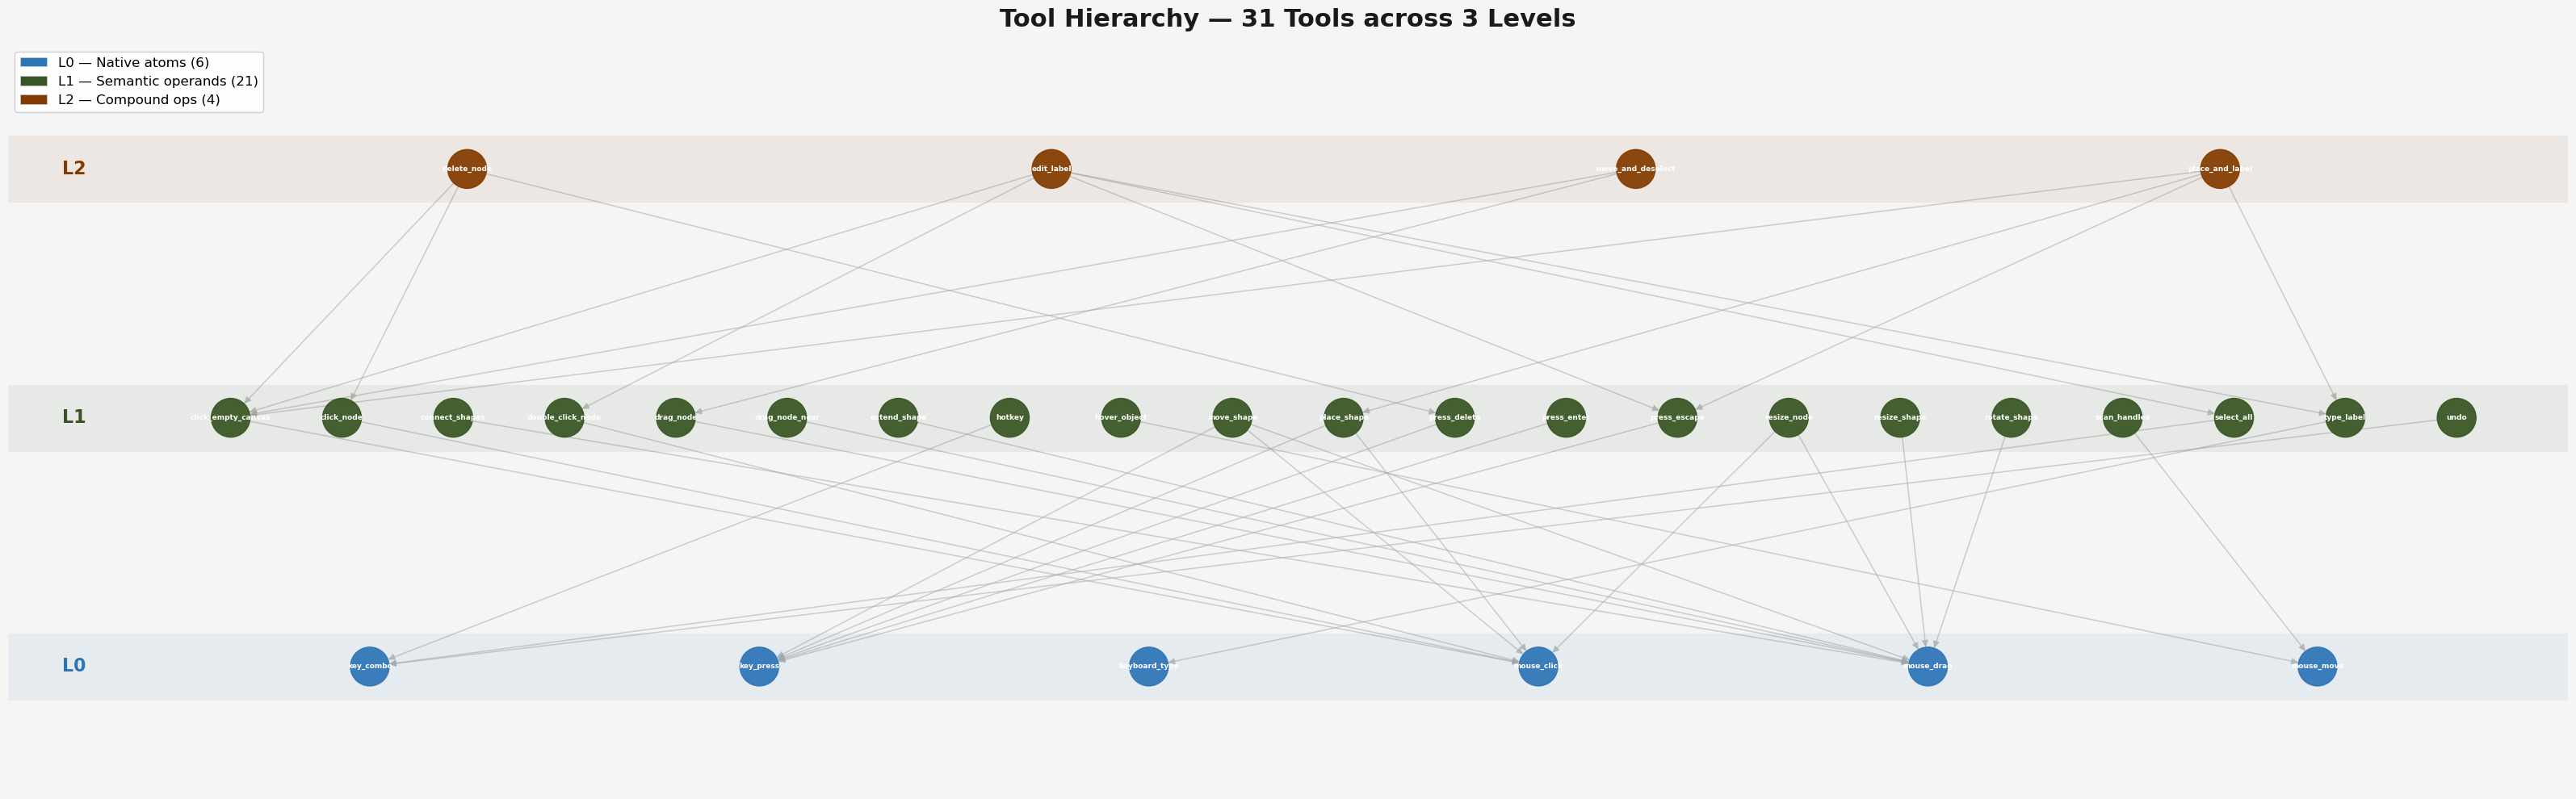

✓ Saved → /Users/zhuyuezx/Documents/UCSD/Spring_2026/CSE252D/drawioDemo/notebooks/tool_tree.png


In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

# ── Build directed graph: edge A→B means "A uses B" ─────────────────
G = nx.DiGraph()
for name, node in TOOL_CATALOG.items():
    G.add_node(name, level=node.level)
for name, node in TOOL_CATALOG.items():
    for child in node.children:
        if child.name in G:
            G.add_edge(name, child.name)

# ── Hierarchical layout: L0 at bottom, L2 at top ─────────────────────
by_level = defaultdict(list)
for name, node in TOOL_CATALOG.items():
    by_level[node.level].append(name)
for lvl in by_level:
    by_level[lvl].sort()

max_count = max(len(ns) for ns in by_level.values())
pos = {}
for lvl, nodes in sorted(by_level.items()):
    n = len(nodes)
    for i, name in enumerate(nodes):
        pos[name] = ((i + 0.5) * max_count / n, lvl * 5.0)

# ── Colour scheme ─────────────────────────────────────────────────────
PALETTE = {0: '#2E75B6', 1: '#375623', 2: '#833C00'}
LEGEND = {
    0: f'L0 \u2014 Native atoms ({sum(1 for n in TOOL_CATALOG.values() if n.level == 0)})',
    1: f'L1 \u2014 Semantic operands ({sum(1 for n in TOOL_CATALOG.values() if n.level == 1)})',
    2: f'L2 \u2014 Compound ops ({sum(1 for n in TOOL_CATALOG.values() if n.level == 2)})',
}
node_colors = [PALETTE[TOOL_CATALOG[n].level] for n in G.nodes()]

# ── Figure ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(32, 10))
fig.patch.set_facecolor('#F5F5F5')
ax.set_facecolor('#F5F5F5')
ax.set_title(
    f'Tool Hierarchy \u2014 {len(TOOL_CATALOG)} Tools across 3 Levels',
    fontsize=22, fontweight='bold', pad=16, color='#1A1A1A',
)

# Subtle horizontal band per level
for lvl in sorted(by_level):
    ax.axhline(lvl * 5.0, color=PALETTE[lvl], alpha=0.07,
               linewidth=60, solid_capstyle='butt')

# Edges (drawn first, behind nodes)
nx.draw_networkx_edges(
    G, pos, ax=ax, arrows=True,
    edge_color='#AAAAAA', alpha=0.55,
    arrowsize=12, arrowstyle='-|>',
    node_size=1200, width=1.1,
)
# Nodes
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors, node_size=1200, alpha=0.93,
)
# Labels
nx.draw_networkx_labels(
    G, pos, ax=ax,
    font_size=6.5, font_color='white', font_weight='bold',
)

# Level labels on left margin
for lvl in sorted(by_level):
    ax.text(-0.8, lvl * 5.0, f'L{lvl}',
            fontsize=16, fontweight='bold', color=PALETTE[lvl],
            va='center', ha='right')

# Legend
patches = [
    mpatches.Patch(facecolor=PALETTE[l], edgecolor='#CCCCCC',
                   linewidth=0.5, label=LEGEND[l])
    for l in sorted(PALETTE)
]
ax.legend(handles=patches, loc='upper left', fontsize=12,
          framealpha=0.95, edgecolor='#CCCCCC', fancybox=True)

ax.set_xlim(-1.5, max_count + 0.5)
ax.set_ylim(-2.5, 12.5)
ax.axis('off')
plt.tight_layout()

out = _here / 'tool_tree.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Saved \u2192 {out}')

In [7]:
# ── Summary table ─────────────────────────────────────────────────────
print(f"{'Level':>7}  {'#':>4}  Tools")
print('─' * 72)
for lvl in sorted(by_level):
    names = ', '.join(by_level[lvl])
    print(f'  L{lvl}      {len(by_level[lvl]):>3}  {names}')
print('─' * 72)
print(f"{'Total':>7}  {len(TOOL_CATALOG):>4}")

  Level     #  Tools
────────────────────────────────────────────────────────────────────────
  L0        6  key_combo, key_press, keyboard_type, mouse_click, mouse_drag, mouse_move
  L1       21  click_empty_canvas, click_node, connect_shapes, double_click_node, drag_node, drag_node_near, extend_shape, hotkey, hover_object, move_shape, place_shape, press_delete, press_enter, press_escape, resize_node, resize_shape, rotate_shape, scan_handles, select_all, type_label, undo
  L2        4  delete_node, edit_label, move_and_deselect, place_and_label
────────────────────────────────────────────────────────────────────────
  Total    31
